# Лабораторная работа №3
## Выполнил студент группы БФИ2201 Балыко Владислав Васильевич


### Цель
Изучить представление графов, алгоритм Дейкстры, визуализацию графов и сравнение производительности на разных размерах входных данных.


### Оглавление
1. Класс графа и алгоритм Дейкстры
2. Чтение графа из матрицы смежности
3. Визуализация графа
4. GUI-интерфейс и измерение времени


In [2]:
import time
import random
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx

try:
    import tkinter as tk
    from tkinter import ttk
    TK_AVAILABLE = True
except ModuleNotFoundError:
    TK_AVAILABLE = False
    print("tkinter не установлен: GUI-часть будет пропущена.")

DATA_DIR = Path('data/Lab3')


tkinter не установлен: GUI-часть будет пропущена.


### Задание 1


In [3]:
class Graph:
    def __init__(self):
        self.nodes = set()
        self.edges = {}

    def add_node(self, value):
        self.nodes.add(value)
        self.edges[value] = []

    def add_edge(self, from_node, to_node, weight):
        self.edges[from_node].append((to_node, weight))


def dijkstra(graph, start):
    distance = {node: float('infinity') for node in graph.nodes}
    distance[start] = 0
    unvisited_nodes = list(graph.nodes)

    while unvisited_nodes:
        current_node = min(unvisited_nodes, key=lambda node: distance[node])
        unvisited_nodes.remove(current_node)

        for neighbor, weight in graph.edges[current_node]:
            new_distance = distance[current_node] + weight
            if new_distance < distance[neighbor]:
                distance[neighbor] = new_distance

    return distance


### Задание 2


In [4]:
def read_graph_from_file():
    graph = Graph()
    with open(DATA_DIR / 'graph_matrix.txt', 'r', encoding='utf-8') as file:
        lines = file.readlines()

    for i, line in enumerate(lines):
        row_values = list(map(int, line.split()))
        graph.add_node(str(i))
        for j, value in enumerate(row_values):
            if value != 0:
                graph.add_edge(str(i), str(j), value)

    return graph


### Задание 3


In [5]:
def visualize_graph(graph):
    G = nx.Graph()
    for node in graph.nodes:
        G.add_node(node)
        for neighbor, weight in graph.edges[node]:
            G.add_edge(node, neighbor, weight=weight)

    pos = nx.spring_layout(G)
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=700,
        node_color='skyblue',
        font_size=10,
        font_color='black',
        font_weight='bold',
        font_family='arial',
    )
    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

    plt.title('Визуализация графа')
    plt.show()


In [6]:
graph = Graph()
graph.add_node('A')
graph.add_node('B')
graph.add_node('C')
graph.add_node('D')

graph.add_edge('A', 'B', 1)
graph.add_edge('B', 'C', 2)
graph.add_edge('C', 'D', 1)
graph.add_edge('A', 'D', 3)

start_node = 'A'
end_node = 'D'
shortest_distances = dijkstra(graph, start_node)

print(f"1) Кратчайшее расстояние от {start_node} до {end_node}: {shortest_distances[end_node]}")


1) Кратчайшее расстояние от A до D: 3


2) Кратчайшее расстояние от 0 до 3: 1


findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.


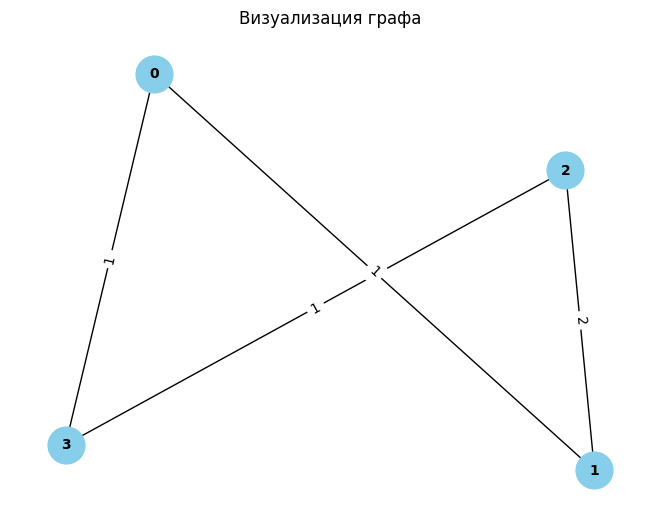

In [7]:
graph = read_graph_from_file()

start_node = '0'
end_node = '3'
shortest_distances = dijkstra(graph, start_node)

print(f"2) Кратчайшее расстояние от {start_node} до {end_node}: {shortest_distances[end_node]}")
visualize_graph(graph)


### Задание 4


In [8]:
def measure_time(func, *args):
    start_time = time.time()
    func(*args)
    end_time = time.time()
    return end_time - start_time


def generate_graph(nodes, edges):
    graph = Graph()

    for i in range(nodes):
        graph.add_node(str(i))

    for _ in range(edges):
        from_node = str(random.randint(0, nodes - 1))
        to_node = str(random.randint(0, nodes - 1))
        weight = random.randint(1, 10)
        graph.add_edge(from_node, to_node, weight)

    return graph

node_counts = [10, 50, 100]
edge_counts = [20, 100, 200]
results_table = []

for nodes in node_counts:
    for edges in edge_counts:
        graph = generate_graph(nodes, edges)
        execution_time = measure_time(dijkstra, graph, '0')
        results_table.append({'Nodes': nodes, 'Edges': edges, 'Time': execution_time})

print('Results Table:')
print('Nodes\tEdges\tTime')
for result in results_table:
    print(f"{result['Nodes']}\t{result['Edges']}\t{result['Time']}")


Results Table:
Nodes	Edges	Time
10	20	3.528594970703125e-05
10	100	5.364418029785156e-05
10	200	4.2438507080078125e-05
50	20	0.0001804828643798828
50	100	0.0002033710479736328
50	200	0.0002205371856689453
100	20	0.0006051063537597656
100	100	0.0006167888641357422
100	200	0.0006792545318603516


### Дополнительно: GUI
Запускай следующую ячейку отдельно, если нужен интерактивный интерфейс `tkinter`.


In [9]:
if not TK_AVAILABLE:
    print('GUI недоступен: установи tkinter в системе и перезапусти ячейку.')
else:
    def show_shortest_distance(graph, start, end):
        shortest_distances = dijkstra(graph, start)
        result_label.config(text=f"Кратчайшее расстояние от {start} до {end}: {shortest_distances[end]}")

    def on_submit():
        start_node = start_var.get()
        end_node = end_var.get()
        show_shortest_distance(graph, start_node, end_node)

    def visualize_graph_button():
        visualize_graph(graph)

    def read_and_visualize_graph():
        global graph
        graph = read_graph_from_file()
        visualize_graph(graph)

    graph = read_graph_from_file()
    root = tk.Tk()
    root.title('Граф и кратчайшее расстояние')

    input_frame = ttk.Frame(root)
    input_frame.pack(pady=10)

    start_label = ttk.Label(input_frame, text='Начальная вершина:')
    start_label.grid(row=0, column=0, padx=5, pady=5)
    start_var = tk.StringVar()
    start_entry = ttk.Entry(input_frame, textvariable=start_var)
    start_entry.grid(row=0, column=1, padx=5, pady=5)

    end_label = ttk.Label(input_frame, text='Конечная вершина:')
    end_label.grid(row=0, column=2, padx=5, pady=5)
    end_var = tk.StringVar()
    end_entry = ttk.Entry(input_frame, textvariable=end_var)
    end_entry.grid(row=0, column=3, padx=5, pady=5)

    submit_button = ttk.Button(input_frame, text='Найти кратчайшее расстояние', command=on_submit)
    submit_button.grid(row=0, column=4, padx=5, pady=5)

    visualize_button = ttk.Button(input_frame, text='Визуализировать граф', command=visualize_graph_button)
    visualize_button.grid(row=0, column=5, padx=5, pady=5)

    visualize_file_button = ttk.Button(input_frame, text='Визуализировать граф из файла', command=read_and_visualize_graph)
    visualize_file_button.grid(row=0, column=6, padx=5, pady=5)

    result_label = ttk.Label(root, text='')
    result_label.pack(pady=10)

    root.mainloop()


GUI недоступен: установи tkinter в системе и перезапусти ячейку.


### Вывод
В лабораторной работе были изучены способы представления графов, реализован алгоритм Дейкстры, визуализация графа и оценка времени работы на разных размерах данных. Полученные результаты подтверждают, что структура графа и выбор алгоритма напрямую влияют на скорость и удобство решения задач поиска кратчайшего пути.
